# KMeans 第六课：初始化与算法局限

K-means 简单高效，但结果依赖初始质心，并隐含了对簇形状、尺度和异常值的假设。

这一课回答：

```text
为什么同一数据可能得到不同结果？
k-means++ 和 n_init 有什么用？
哪些数据不适合 K-means？
```

In [1]:
import os

# sklearn 1.7.x 在 Windows + MKL 的小数据集上建议限制 OpenMP 线程数
os.environ["OMP_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

np.set_printoptions(precision=3, suppress=True)

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

## 1. 局部最优与随机初始化

K-means 每轮都会让 SSE 不增大，但这只保证收敛到某个局部最优解。

随机选择的初始质心不同，算法走过的路径可能不同，最终 `inertia_` 也可能不同。

`n_init=1` 只尝试一次；`n_init=10` 会尝试 10 组初始化并保留 inertia 最小的结果。

In [2]:
X_challenging, _ = make_blobs(
    n_samples=500,
    centers=[(-6, -1), (-2, 1), (2, -1), (6, 1)],
    cluster_std=[1.6, 1.4, 1.5, 1.6],
    random_state=7,
)

random_inertias = []
plus_inertias = []

for seed in range(20):
    random_model = KMeans(
        n_clusters=4, init="random", n_init=1, random_state=seed
    ).fit(X_challenging)
    plus_model = KMeans(
        n_clusters=4, init="k-means++", n_init=1, random_state=seed
    ).fit(X_challenging)
    random_inertias.append(random_model.inertia_)
    plus_inertias.append(plus_model.inertia_)

print("random 初始化 inertia 范围:", min(random_inertias), max(random_inertias))
print("k-means++ inertia 范围:", min(plus_inertias), max(plus_inertias))

random 初始化 inertia 范围: 1912.1047608114202 1913.9627355775538
k-means++ inertia 范围: 1912.1047608114202 1913.9627355775538


## 2. k-means++ 的直觉

`k-means++` 不会把所有初始质心随便挤在同一区域。

简化理解：

```text
先选择一个质心
-> 离已有质心越远的样本，越有机会成为下一个质心
-> 让初始质心尽量分散
```

它仍有随机性，但通常比完全随机初始化更稳定。实际使用建议：

```python
KMeans(init="k-means++", n_init=10, random_state=22)
```

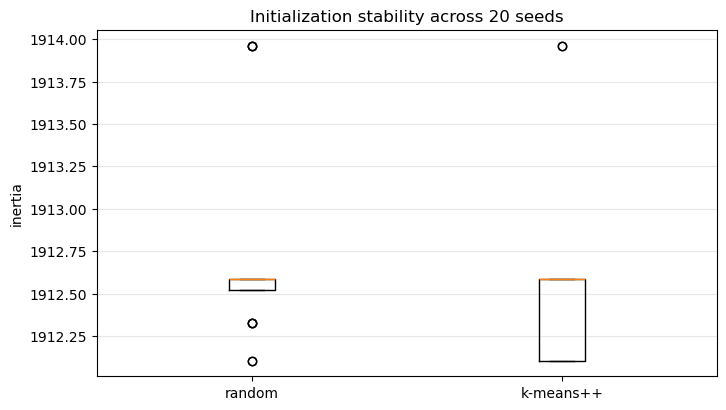

In [3]:
plt.figure(figsize=(8, 4.5))
plt.boxplot([random_inertias, plus_inertias], tick_labels=["random", "k-means++"])
plt.title("Initialization stability across 20 seeds")
plt.ylabel("inertia")
plt.grid(axis="y", alpha=0.3)
plt.show()

## 3. 异常值会拉动均值质心

K-means 的质心是均值，而均值对极端值敏感。

下面先计算一组正常样本的单簇质心，再加入一个远离主体的异常值。

In [4]:
normal_points = np.array([
    [0.0, 0.0], [0.2, -0.1], [-0.2, 0.1], [0.1, 0.2], [-0.1, -0.2]
])
outlier = np.array([[12.0, 12.0]])

center_without_outlier = KMeans(
    n_clusters=1, n_init=10, random_state=22
).fit(normal_points).cluster_centers_[0]
center_with_outlier = KMeans(
    n_clusters=1, n_init=10, random_state=22
).fit(np.vstack([normal_points, outlier])).cluster_centers_[0]

print("没有异常值的质心:", center_without_outlier)
print("加入异常值后的质心:", center_with_outlier)

没有异常值的质心: [0. 0.]
加入异常值后的质心: [2. 2.]


处理异常值不能只有一个固定答案，常见做法包括：

- 检查数据质量并修正错误值；
- 根据业务规则截尾或变换；
- 使用稳健缩放；
- 改用对异常值更稳健的聚类方法。

不能为了让图好看而随意删除真实样本。

## 4. 非球形簇：月牙数据

K-means 按“离哪个质心更近”划分空间，得到的区域由直线边界组成。

它更擅长：

```text
近似球形 / 圆形
大小相近
密度相近
欧氏距离有意义
```

两个弯曲月牙不满足这些条件。

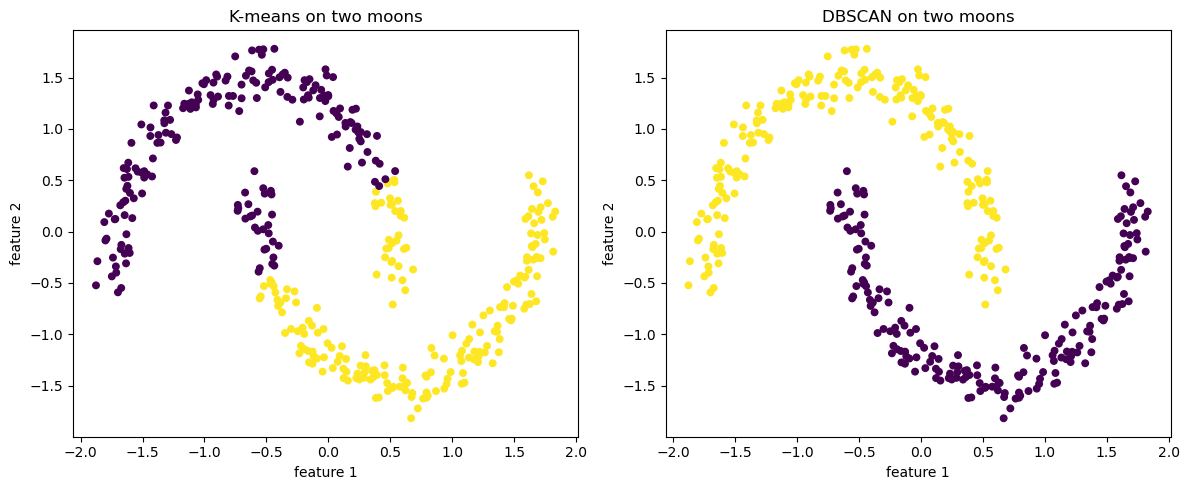

In [5]:
X_moons, _ = make_moons(n_samples=400, noise=0.06, random_state=22)
X_moons = StandardScaler().fit_transform(X_moons)

kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=22)
kmeans_moon_labels = kmeans_moons.fit_predict(X_moons)

dbscan = DBSCAN(eps=0.25, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=kmeans_moon_labels, cmap="viridis", s=22)
axes[0].set_title("K-means on two moons")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_labels, cmap="viridis", s=22)
axes[1].set_title("DBSCAN on two moons")
for ax in axes:
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")
plt.tight_layout()
plt.show()

图中的目的不是宣布 DBSCAN 永远更好，而是说明：算法的几何假设必须与数据结构匹配。

## 5. K-means 的其他限制

### 必须提前给出 K

如果没有领域知识或清晰指标，选择 K 可能含糊。

### 主要处理数值特征

类别变量不能随便编码成 `0/1/2` 后直接计算欧氏距离，因为数字差值未必代表类别相似度。

### 高维距离可能失去区分度

特征很多时，噪声维度会干扰距离。需要特征选择、降维或更合适的相似度。

### 不同密度与不同大小

K-means 可能拆开大簇，或把相邻小簇合并。

## 6. 什么时候适合使用 K-means？

```text
数据以数值特征为主
特征尺度已合理处理
簇近似球形且密度相近
数据量较大，需要快速算法
希望得到明确的 K 个中心
```

## 7. 本课小结

- K-means 收敛不等于全局最优；
- `k-means++` 改善初始质心分布；
- `n_init` 通过多次初始化降低偶然性；
- 均值质心使算法对异常值敏感；
- 月牙、环形、不同密度数据通常不是 K-means 的强项；
- 使用算法前要检查它的几何假设。

下一课用 Iris 完成综合案例。